In [145]:
import pandas as pd
import numpy as np
from src.common.utils import get_root_directory
import matplotlib.pyplot as plt
import numpy as np
from src.preprocessing.data_loader import DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import mlflow
import mlflow.sklearn
from darts.models import RandomForest, XGBModel
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
import shap
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler

In [146]:
def collate_array_elements(arrays):
    if not arrays:
        return []
    return [list(group) for group in zip(*arrays)]

### Train-Validation-Test Split

In [371]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.final_data.columns

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol'],
      dtype='object')

In [372]:
selected_features = ['ETH_D_AvgPrc', 'ETH_YF_Hi', 'ETH_YF_Lo']
DL.select_features(features=selected_features)

In [373]:
DL.set_time_range(start_date="01/01/2021", end_date="31/12/2023")
train, test = DL.split_data(split_size=0.15)
train, val = DL.split_data(split_type="train_val", split_size=0.15)

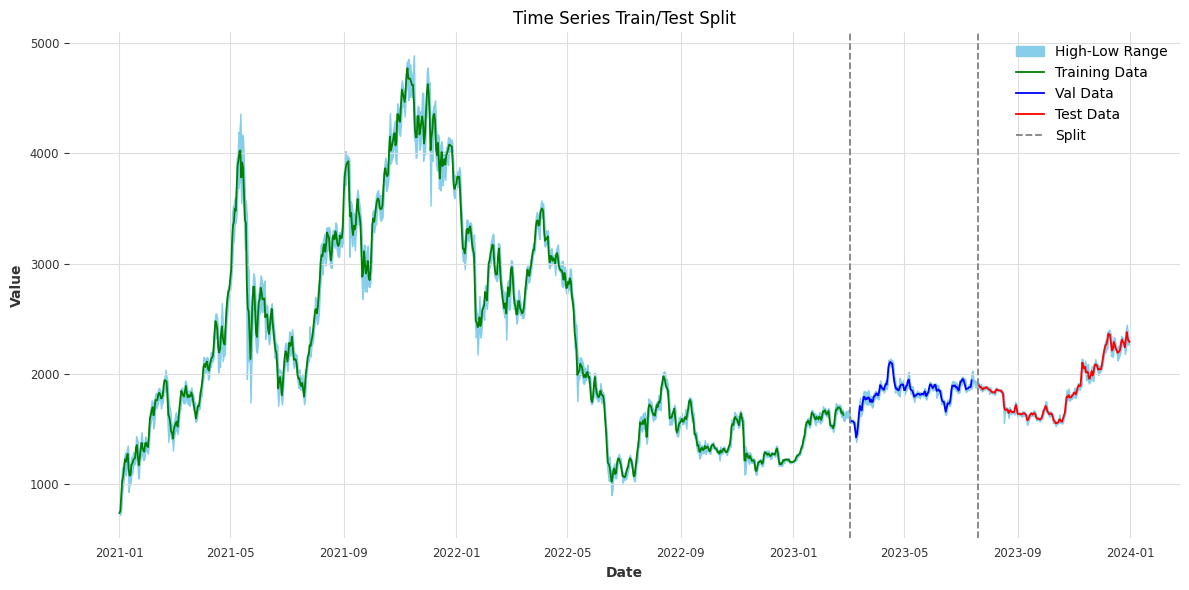

In [375]:
plt.figure(figsize=(12, 6))
plt.fill_between(DL.final_data.index, DL.final_data['ETH_YF_Hi'], DL.final_data['ETH_YF_Lo'], color='skyblue', label='High-Low Range')
plt.plot(train[:-7].index, train['ETH_D_AvgPrc'][:-7].values, label='Training Data', color='green')
plt.plot(val[:-7].index, val['ETH_D_AvgPrc'][:-7].values, label='Val Data', color='blue')
plt.plot(test.index, test['ETH_D_AvgPrc'].values, label='Test Data', color='red')
plt.axvline(train.index[-1], color='gray', linestyle='--', label='Split')
plt.axvline(val.index[-1], color='gray', linestyle='--')

# Labels and legend
plt.title('Time Series Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Feature Selection

In [155]:
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15

In [156]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
publishers = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
DL.merge_selected_data(selected_data=['BTC','LTC','sentiment_analysis'])
DL.final_data.columns

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'BTC_D_AvgPrc', 'BTC_YF_Op', 'BTC_YF_Hi', 'BTC_YF_Lo', 'BTC_YF_Cls',
       'BTC_YF_Vol', 'BTC_OL_MktCap', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr',
       'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd',
       'BTC_OL_ChnTrans', 'BTC_OL_ChnVol', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc',
       'LTC_YF_Op', 'LTC_YF_Hi', 'LTC_YF_Lo', 'LTC_YF_Cls', 'LTC_YF_Vol',
       'LTC_OL_MktCap', 'LTC_OL_BlkSz', 'LTC_OL_AvgComPwr',
       'LTC_OL_AvgTransFee', 'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd',
       'LTC_OL_ChnTrans', 'LTC_BIC_HshRt', 'D_VADER_AvgScr_In',
       'D_VADER_Sent_AvgIn', 'D_VADE

In [157]:
selected_features = ['ETH_D_AvgPrc','ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc','ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd','ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon','ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol']
DL.select_features(features=selected_features)
# lag_config = {'ETH_D_AvgPrc':5}
# DL.lag_features(lag_config=lag_config)
# DL.generate_forecast_horizon(horizon=n_periods)
DL.set_time_range(start_date=start_date, end_date=end_date)

In [158]:
train, test = DL.split_data(split_size=split_size)
# train, val = DL.split_data(split_type="train_val", split_size=split_size)
# features = [col for col in train.columns if 'lag' in col]
# targets = [col for col in train.columns if'horizon' in col]
features = [col for col in train.columns if col!='ETH_D_AvgPrc']
targets = ['ETH_D_AvgPrc']
# x_scaler=MinMaxScaler()
# y_scaler=MinMaxScaler()
y_train, x_train = train[targets], train[features]
# # y_val, x_val = val[targets], val[features]
# y_test, x_test = test[targets], test[features]
# y_train_gapped, x_train_gapped = y_train[:-n_periods], x_train[:-n_periods]
# # y_val_gapped, x_val_gapped = y_val[:-n_periods], x_val[:-n_periods]
# y_test_gapped, x_test_gapped = y_test[:-n_periods], x_test[:-n_periods]
# y_train_scaled= pd.DataFrame(y_scaler.fit_transform(y_train), columns=y_train.columns, index=y_train.index)
# x_train_scaled = pd.DataFrame(x_scaler.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
# y_train_gapped_scaled = pd.DataFrame(y_scaler.transform(y_train_gapped), columns=y_train_gapped.columns, index=y_train_gapped.index)
# x_train_gapped_scaled = pd.DataFrame(x_scaler.transform(x_train_gapped), columns=x_train_gapped.columns, index=x_train_gapped.index)
# y_test_scaled = pd.DataFrame(y_scaler.transform(y_test), columns=y_test.columns, index=y_test.index)
# x_test_scaled = pd.DataFrame(x_scaler.transform(x_test), columns=x_test.columns, index=x_test.index)
# y_test_gapped_scaled = pd.DataFrame(y_scaler.transform(y_test_gapped), columns=y_test_gapped.columns, index=y_test_gapped.index)
# x_test_gapped_scaled = pd.DataFrame(x_scaler.transform(x_test_gapped), columns=x_test_gapped.columns, index=x_test_gapped.index)

In [159]:
# XGB = XGBRegressor(random_state=42)
# XGB.fit(x_train_gapped_scaled, y_train_gapped_scaled)
RF = RandomForestRegressor(random_state=42, n_estimators=100)
RF.fit(x_train, y_train)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [35]:
forecast = XGB.predict(x_test_scaled[50:51])

In [36]:
reverse = y_scaler.inverse_transform(forecast)

In [37]:
reverse

array([[1625.754 , 1592.0829, 1584.7738, 1583.3086, 1534.5897, 1592.8048,
        1675.0729]], dtype=float32)

In [41]:
y_true = y_scaler.inverse_transform(y_test_scaled[50:51])
y_true

array([[1634.43609619, 1622.87854004, 1580.03500366, 1578.13375854,
        1599.53717041, 1620.81600952, 1633.46807861]])

In [40]:
rsme = root_mean_squared_error(y_true, reverse)
print(rsme)

26.27925763811384


In [162]:
RF.feature_importances_

array([0.01001584, 0.54192696, 0.00719122, 0.00768817, 0.07151313,
       0.01152659, 0.01744387, 0.00902365, 0.16080707, 0.11092498,
       0.01268004, 0.01859374, 0.01492836, 0.00573636])

In [164]:
x_train.columns

Index(['ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc', 'ETH_ES_BlkCnt',
       'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd', 'ETH_ES_DepCon',
       'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon', 'ETH_OL_NewAdd',
       'ETH_OL_ChnTrans', 'ETH_OL_ChnVol'],
      dtype='object')

In [161]:
explainer = shap.TreeExplainer(RF, x_train)
shap_values = explainer(x_train)
avg = shap_values

 99%|===================| 925/931 [00:26<00:00]        

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\rajdh\\Desktop\\ETH_Price_Predition\\reports\\figures\\feature_selection\\RF\\All.jpg'

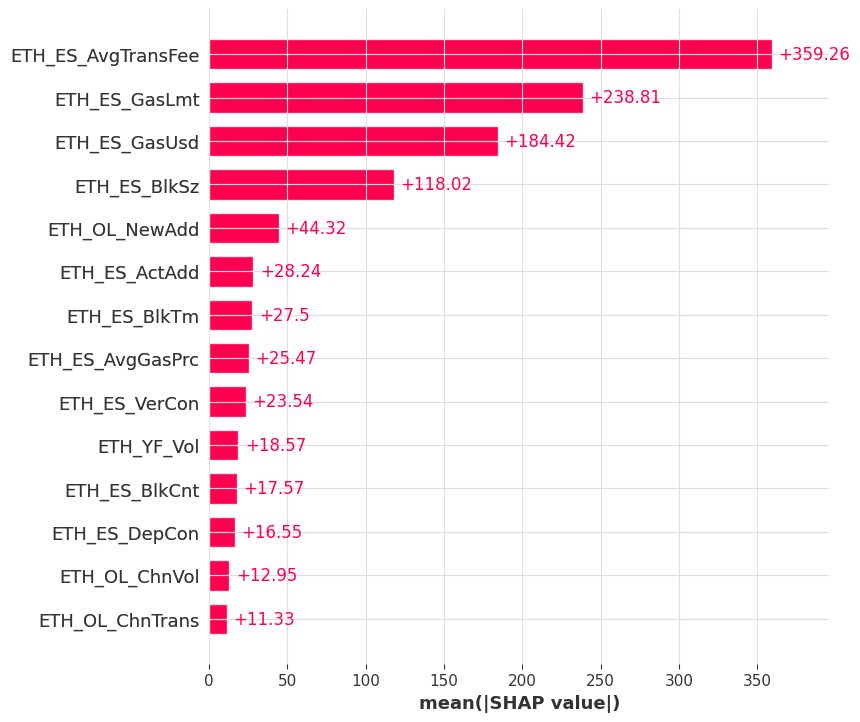

In [163]:
shap.plots.bar(shap_values=avg, max_display=100, show=False)
model = "RF"
plt.savefig(f"{root_dir}\\reports\\figures\\feature_selection\\{model}\\All.jpg", format="jpg", bbox_inches='tight', dpi=400)

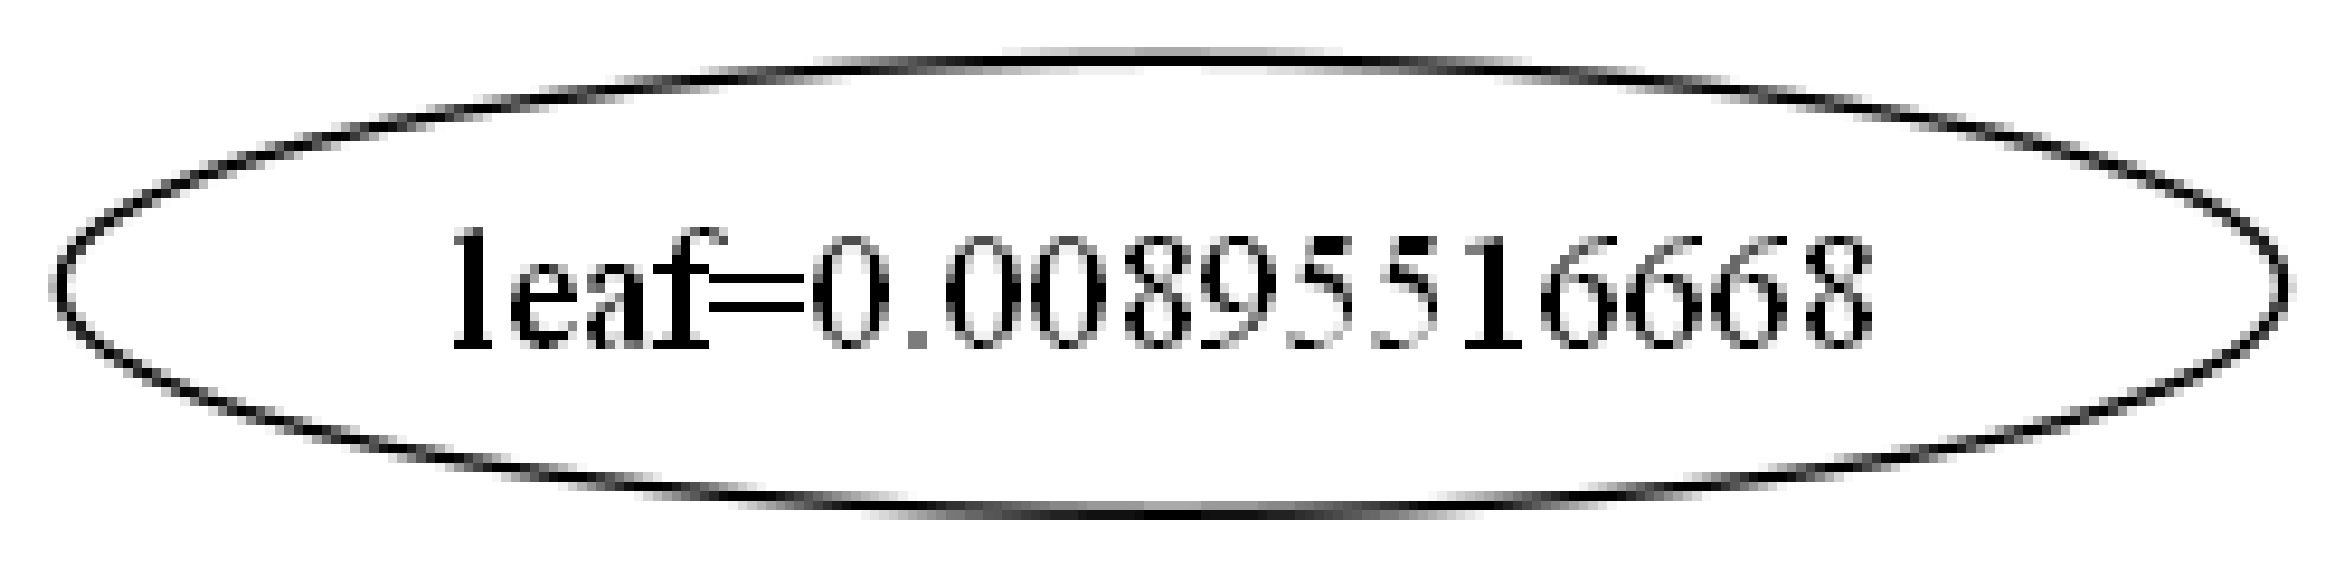

In [12]:
from xgboost import XGBRegressor, plot_tree
import matplotlib.pyplot as plt

plot_tree(XGB)
fig = plt.gcf()
fig.set_size_inches(30, 15)  # optional: resize
plt.savefig("xgboost_tree_gamma.png", dpi=300, bbox_inches='tight')  # Save the figure
plt.show()

## ETH Blockchain Features Manual

In [128]:
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15

In [129]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
publishers = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
DL.merge_selected_data(selected_data=['BTC','LTC','sentiment_analysis'])

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

In [130]:
lag_config = {'ETH_D_AvgPrc':5}
DL.lag_features(lag_config=lag_config)
DL.generate_forecast_horizon(horizon=n_periods)
DL.set_time_range(start_date=start_date, end_date=end_date)
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_type="train_val", split_size=split_size)
features = [col for col in train.columns if 'lag' in col]
targets = [col for col in train.columns if'horizon' in col]

Column ETH_D_PrcDir not found in lag_config, removing the column from the dataset.
Column ETH_YF_Op not found in lag_config, removing the column from the dataset.
Column ETH_YF_Hi not found in lag_config, removing the column from the dataset.
Column ETH_YF_Lo not found in lag_config, removing the column from the dataset.
Column ETH_YF_Cls not found in lag_config, removing the column from the dataset.
Column ETH_YF_Vol not found in lag_config, removing the column from the dataset.
Column ETH_ES_AvgTransFee not found in lag_config, removing the column from the dataset.
Column ETH_ES_AvgGasPrc not found in lag_config, removing the column from the dataset.
Column ETH_ES_BlkCnt not found in lag_config, removing the column from the dataset.
Column ETH_ES_BlkSz not found in lag_config, removing the column from the dataset.
Column ETH_ES_BlkTm not found in lag_config, removing the column from the dataset.
Column ETH_ES_ActAdd not found in lag_config, removing the column from the dataset.
Colum

In [141]:
y_train, x_train = train[targets].to_numpy(), train[features].to_numpy()
y_val, x_val = val[targets].to_numpy(), val[features].to_numpy()
y_test, x_test = test[targets].to_numpy(), test[features].to_numpy()
y_train_gapped, x_train_gapped = y_train[:-n_periods], x_train[:-n_periods]
y_val_gapped, x_val_gapped = y_val[:-n_periods], x_val[:-n_periods]
y_test_gapped, x_test_gapped = y_test[:-n_periods], x_test[:-n_periods]

In [142]:
predictions = []
experiment_name = "XGB_model_tuning_validation_manual"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name=f"ETH_lag"):
    XGB = XGBRegressor(random_state=42, gamma=200000000)
    for t in range(len(y_val_gapped)):
        XGB.fit(x_train_gapped, y_train_gapped)
        forecast = XGB.predict(x_val_gapped[t:t+1])
        predictions.append(forecast.flatten().tolist())
        y_train_gapped = np.vstack((y_train_gapped, y_train[-n_periods]))
        x_train_gapped = np.vstack((x_train_gapped, x_train[-n_periods]))
        y_train = np.vstack((y_train, y_val[t:t+1]))
        x_train = np.vstack((x_train, x_val[t:t+1]))
        # y_train = y_train.append_values(y_test[t:t+1])
        # x_train = x_train.append_values(x_test[t:t+1])
    mse_list = []
    rmse_list = []
    mae_list = []
    mape_list = []
    transposed = collate_array_elements(predictions)
    for i in range(len(transposed)):
        mse = mean_squared_error(y_val[i:-n_periods+i,i], transposed[i])
        rmse = root_mean_squared_error(y_val[i:-n_periods+i,i], transposed[i])
        mae = mean_absolute_error(y_val[i:-n_periods+i,i], transposed[i])
        mape = mean_absolute_percentage_error(y_val[i:-n_periods+i,i], transposed[i])
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
        mlflow.log_metrics({"mse_daily":mse_list[i], "rmse_daily":rmse_list[i], "mae_daily":mae_list[i], "mape_daily":mape_list[i]}, step=(i+1))
    avg_mse = sum(mse_list)/len(mse_list)
    avg_rmse = sum(rmse_list)/len(rmse_list)
    avg_mae = sum(mae_list)/len(mae_list)
    avg_mape = sum(mape_list)/len(mape_list)
    mlflow.log_metrics({"avg_mse": avg_mse, "avg_rmse": avg_rmse, "avg_mae": avg_mae, "avg_mape": avg_mape})
    mlflow.end_run()

In [144]:
rmse_list

[190.28000829611673,
 183.86085498153466,
 179.9367105694405,
 164.12393501455944,
 155.52307927479072,
 150.26104830070102,
 144.7173643351269]

# ETH BlockChain Features

In [59]:
DL = DataLoader(root_dir)
DL.load_data()
publishers = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
DL.merge_selected_data(selected_data=['BTC','LTC','sentiment_analysis'], select_publishers=publishers)
DL.final_data.columns

Pandas Apply:   0%|          | 0/2353 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2353 [00:00<?, ?it/s]

C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\feature_generator.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.input_data[col_score_In] = (


Pandas Apply:   0%|          | 0/2353 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2353 [00:00<?, ?it/s]

C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\feature_generator.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.input_data[col_score_In] = (


Pandas Apply:   0%|          | 0/2353 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2353 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'BTC_D_AvgPrc', 'BTC_YF_Op', 'BTC_YF_Hi', 'BTC_YF_Lo', 'BTC_YF_Cls',
       'BTC_YF_Vol', 'BTC_OL_MktCap', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr',
       'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd',
       'BTC_OL_ChnTrans', 'BTC_OL_ChnVol', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc',
       'LTC_YF_Op', 'LTC_YF_Hi', 'LTC_YF_Lo', 'LTC_YF_Cls', 'LTC_YF_Vol',
       'LTC_OL_MktCap', 'LTC_OL_BlkSz', 'LTC_OL_AvgComPwr',
       'LTC_OL_AvgTransFee', 'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd',
       'LTC_OL_ChnTrans', 'LTC_BIC_HshRt', 'D_VADER_AvgScr_In',
       'D_VADER_Sent_AvgIn', 'D_VADE

In [60]:
selected_features = ['ETH_D_AvgPrc','BTC_D_AvgPrc']
DL.select_features(features=selected_features)
DL.set_time_range(start_date=start_date, end_date=end_date)
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_type="train_val", split_size=split_size)
# train_gapped = train[:-n_periods]
# val_gapped = val[:-n_periods]
features = [col for col in train.columns if col != 'ETH_D_AvgPrc']

In [61]:
experiment_name = "XGB_model_tuning_validation"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
# lag_config={'D_VADER_AvgScr_Ex':[-1,-2,-3,-4,-5],'LTC_D_AvgPrc': [-1, -2, -3, -4, -5], 'LTC_OL_NewAdd': [-1, -2, -3, -4], 'LTC_OL_MinDif': [-5], 'LTC_OL_AvgComPwr': [-1]}
# lag_config = {col:[-1,-2,-3,-4,-5,-6,-7,-8,-9,-10] for col in selected_features if col !='ETH_D_AvgPrc' }
lag_config = {'ETH_D_AvgPrc':[-1]}
# train = TimeSeries.from_dataframe(train)
# train_gapped = TimeSeries.from_dataframe(train_gapped)
# for max_depth in [6,8,10]:
#     for min_child_weight in [0,1,3]:
#         for gamma in [0,1,10]:
#             for reg_lambda in [0.1,0.5,1,1.5]:
predictions = []
y_train = TimeSeries.from_dataframe(pd.DataFrame(train['ETH_D_AvgPrc']))
x_train = TimeSeries.from_dataframe(train[features])
y_val = val['ETH_D_AvgPrc']
x_val = val[features]
# y_test = test['ETH_D_AvgPrc']
# x_test = test[features]
# y_train_gapped= y_train[:-n_periods]
# y_val_gapped = y_val[:-n_periods]
# y_test_gapped = y_test[:-n_periods]
y_train_gapped, x_train_gapped = y_train[:-n_periods], x_train[:-n_periods]
y_val_gapped, x_val_gapped = y_val[:-n_periods], x_val[:-n_periods]
# y_test_gapped, x_test_gapped = y_test[:-n_periods], x_test[:-n_periods]

with mlflow.start_run(run_name=f"ETH_lag"):
    mlflow.log_params({"lag_config":lag_config})
    model = XGBModel(lags=[-1], random_state=42, output_chunk_length=n_periods, gamma=100000)
    for t in range(len(y_val_gapped)):
        model.fit(series=y_train_gapped)
        forecast = model.predict(n=n_periods, series=y_train)
        predictions.append(forecast.values().flatten().tolist())
        y_train_gapped = y_train_gapped.append_values(y_train[-n_periods].values().flatten())
        # x_train_gapped = x_train_gapped.append_values(x_train[-n_periods].values())
        y_train = y_train.append_values(y_val[t:t+1])
        # x_train = x_train.append_values(x_val[t:t+1])
        # y_train = y_train.append_values(y_test[t:t+1])
        # x_train = x_train.append_values(x_test[t:t+1])
    mse_list = []
    rmse_list = []
    mae_list = []
    mape_list = []
    transposed = collate_array_elements(predictions)
    for i in range(len(transposed)):
        mse = mean_squared_error(y_val[i:-n_periods+i], transposed[i])
        rmse = root_mean_squared_error(y_val[i:-n_periods+i], transposed[i])
        mae = mean_absolute_error(y_val[i:-n_periods+i], transposed[i])
        mape = mean_absolute_percentage_error(y_val[i:-n_periods+i], transposed[i])
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
        mlflow.log_metrics({"mse_daily":mse_list[i], "rmse_daily":rmse_list[i], "mae_daily":mae_list[i], "mape_daily":mape_list[i]}, step=(i+1))
    avg_mse = sum(mse_list)/len(mse_list)
    avg_rmse = sum(rmse_list)/len(rmse_list)
    avg_mae = sum(mae_list)/len(mae_list)
    avg_mape = sum(mape_list)/len(mape_list)
    mlflow.log_metrics({"avg_mse": avg_mse, "avg_rmse": avg_rmse, "avg_mae": avg_mae, "avg_mape": avg_mape})
    mlflow.end_run()